# 01: Coverage

*How completely does each knowledge graph represent the biomedical entities and relations relevant to drug repurposing?*

This notebook evaluates **coverage** across all KGs listed in `config.yaml`, measuring the breadth of entities and relation types represented relative to gold-standard references.

| Metric | Definition | Quantification | Scoring |
|--------|-----------|----------------|---------|
| **Entity coverage** | Fraction of gold-standard biomedical entities present in the KG, per entity type | \|KG ∩ gold\| / \|gold\| per shared canonical type (drugs: DrugBank; genes: UniProt/Entrez; diseases: Disease Ontology; pathways: Reactome); macro-averaged across shared types | Direct proportion (0–1); no transformation |
| **Relation coverage** | Fraction of known gold-standard relation pairs present in the KG, per relation type | \|KG pairs ∩ gold pairs\| / \|gold pairs\| per shared relation type (drug–target: DrugBank; drug–disease indications: Open Targets; drug–drug interactions: DrugBank); macro-averaged across shared types | Direct proportion (0–1); no transformation |
| **Dimension score** | — | — | Equal-weighted mean of entity coverage and relation coverage |

**Inputs:** `config.yaml` · `data/gold_standards/` (DrugBank, UniProt, Disease Ontology, Reactome, Open Targets, MESH–DOID bridge)

**Outputs:** `results/figures/01_entity_coverage.{pdf,png}` · `results/figures/01_relation_coverage.{pdf,png}` · `results/checkpoints/01_coverage.pkl` · `results/coverage/*.csv`

**Dependencies:** `src/loading.py` · `src/plotting.py`

## Set-up

KGs are loaded from paths defined in `config.yaml`. Each KG's entity-type name mappings, relation identifiers, and disease-ID normalisation strategy are also read from config — add a new KG block to `config.yaml` to include it without modifying notebook code.

Gold-standard reference sets are loaded from `data/gold_standards/`:

| Reference | Source | ID type |
|-----------|--------|---------|
| DrugBank drugs | `drugbank_drugs.csv` | DrugBank accession (DB*) |
| UniProt genes | `uniprot_genesproteins.csv` | Entrez Gene ID |
| Disease Ontology | `do_diseases.csv` | DOID numeric |
| Reactome pathways | `reactome_pathways.csv` | Reactome stable ID (R-HSA-*) |
| Open Targets indications | `opentargets_drug_indications.csv` | (DrugBank, MONDO) pairs |
| DrugBank DDIs | `drugbank_ddi.csv` | (DrugBank, DrugBank) pairs |

Coverage is computed exactly over the full entity and relation sets — no sampling.

In [1]:
# Imports
import sys, os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import Optional

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from src.plotting import setup_style, save_fig, TEXT_COLOR, TICK_COLOR, KG_PALETTE, HEATMAP_CMAP
from src.loading  import find_config, load_config, load_kg

setup_style()

In [2]:
# Config and paths
config = load_config(find_config(_root))
params = config['analysis_params']
BASE   = config['_base_dir']
GOLD   = BASE / 'data' / 'gold_standards'
FIGS   = BASE / 'results' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)


def _style_left_spine(ax):
    """Hide top/right/bottom spines; style left spine for clean axis presentation."""
    for sp in ('top', 'right', 'bottom'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['left'].set_linewidth(0.5)


def _style_bottom_spine(ax):
    """Hide top/right/left spines; style bottom spine (used for horizontal bar charts)."""
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('#333333')
    ax.spines['bottom'].set_linewidth(0.5)

### Loading

In [3]:
# Load KGs - skips any not found or erroring gracefully
kgs = {}
for name in config['knowledge_graphs']:
    try:
        kg, nodes = load_kg(name, config)
        kgs[name] = {'kg': kg, 'nodes': nodes}
        print(f'{name:12s}: {len(kg):>12,} edges  {len(nodes):>8,} nodes  '
              f'{kg["relation"].nunique():>4} relation types')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

KG_NAMES = list(kgs.keys())
LOADED   = [n for n in kgs if config['knowledge_graphs'].get(n, {}).get('relations')]

primekg     :    8,100,498 edges   129,375 nodes    30 relation types
hetionet    :    2,250,197 edges    47,031 nodes    24 relation types
drkg        :    5,874,261 edges    97,238 nodes   107 relation types
openbilink  :    4,986,521 edges   185,929 nodes    28 relation types
biokg       :    2,067,998 edges   105,524 nodes    17 relation types


In [4]:
# KG metadata derived from config - drives all downstream cells
ENTITY_TYPE_MAP = {n: config['knowledge_graphs'][n].get('entity_types', {}) for n in KG_NAMES}
KG_RELATIONS    = {n: config['knowledge_graphs'][n].get('relations',     {}) for n in KG_NAMES}
PATHWAY_KGS     = {n for n in KG_NAMES
                   if config['knowledge_graphs'][n].get('pathway_ontology') == 'reactome'}
KG_COLORS       = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}

## 1. Entity Coverage

Entity coverage quantifies how many gold-standard entities of each type are represented in a KG:

$$\text{Entity Coverage}_t = \frac{|\text{KG}_t \cap \text{Gold}_t|}{|\text{Gold}_t|}$$

where $t$ is the entity type (Drug, Disease, Gene/Protein, Pathway).

**ID normalisation.** Entity-type mappings and disease-ID normalisation strategies are specified per KG in `config.yaml`:
- **Drug** — DrugBank accessions, matched natively.
- **Gene/Protein** — Entrez Gene IDs, matched natively.
- **Disease** — normalised to DOID numeric strings. Per-KG scheme: `mondo` (bridged via MONDO→DOID), `doid` (strip prefix), or `doid_mesh` (bridge MESH IDs via MESH→DOID table).
- **Pathway** — Reactome `R-HSA-*` IDs. Restricted to KGs with `pathway_ontology: reactome`; other ontologies are incommensurable and reported as N/A.

### Gold Standards

Reference files are loaded once and shared across all entity types. Drug and gene IDs are matched natively (DrugBank accession / Entrez); disease IDs require per-KG normalisation (see scheme below); pathway coverage applies only to KGs using Reactome ontology.

In [5]:
# Gold standard reference sets
drugbank     = pd.read_csv(GOLD / 'drugbank_drugs.csv',              low_memory=False)
drugbank_ddi = pd.read_csv(GOLD / 'drugbank_ddi.csv')
do           = pd.read_csv(GOLD / 'do_diseases.csv')
mesh_doid_df = pd.read_csv(GOLD / 'mesh_to_doid.csv',               on_bad_lines='skip')
uniprot      = pd.read_csv(GOLD / 'uniprot_genesproteins.csv',       low_memory=False)
reactome     = pd.read_csv(GOLD / 'reactome_pathways.csv')
ot_ind       = pd.read_csv(GOLD / 'opentargets_drug_indications.csv',    low_memory=False)

In [6]:
# Utility helpers - ID normalisation and coverage calculation

def _as_str_set(series: pd.Series) -> set:
    """Series -> normalised string set (strips whitespace, drops nulls and empty strings)."""
    return set(series.dropna().astype(str).str.strip()) - {''}


def _strip_prefix(id_str: str) -> str:
    """Strip type prefix: 'Compound::DB00001' -> 'DB00001'."""
    s = str(id_str).strip()
    return s.split('::')[-1] if '::' in s else s


def entity_set_from_kg(kg: pd.DataFrame, entity_type: str) -> set:
    """Unique bare node IDs for entity_type from an edge table."""
    raw = _as_str_set(pd.concat([
        kg.loc[kg['x_type'] == entity_type, 'x_id'],
        kg.loc[kg['y_type'] == entity_type, 'y_id'],
    ], ignore_index=True))
    return {_strip_prefix(i) for i in raw}


def calc_coverage(kg_set: set, gold_set: set) -> dict:
    """Coverage = |KG & Gold| / |Gold|."""
    overlap = kg_set & gold_set
    n_gold  = len(gold_set)
    return {
        'kg_n':         len(kg_set),
        'gold_n':       n_gold,
        'overlap_n':    len(overlap),
        'coverage_pct': round(100 * len(overlap) / n_gold, 2) if n_gold else float('nan'),
        'matched':      overlap,
        'unmatched':    gold_set - kg_set,
    }

### Reference data

In [7]:
# Drugs - approved and investigational only
drugbank_relevant = drugbank[drugbank['is_approved'] | drugbank['is_investigational']]
gold_drugs        = _as_str_set(drugbank_relevant['drugbank_id'])
_db_all_ids       = _as_str_set(drugbank['drugbank_id'])

# Diseases - DOID numeric strings
gold_diseases_doid = set(
    do['doid'].str.replace('DOID:', '', regex=False).str.lstrip('0')
) - {''}

# MONDO <-> DOID bridge
_do_map = (do.dropna(subset=['mondo_id', 'doid'])
             .sort_values('doid')
             .drop_duplicates(subset='mondo_id', keep='first'))
mondo_to_doid = {
    r['mondo_id'].replace('MONDO:', '').lstrip('0'): r['doid'].replace('DOID:', '').lstrip('0')
    for _, r in _do_map.iterrows()
}
doid_to_mondo = {v: k for k, v in mondo_to_doid.items()}

# MESH -> DOID bridge - prefer DO-sourced mappings over MONDO
mesh_doid_df['mesh_id_clean'] = (mesh_doid_df['mesh_id']
                                 .str.replace(r'\s*\{.*\}', '', regex=True).str.strip())
_mesh_dedup = (mesh_doid_df
               .assign(src_rank=mesh_doid_df['source'].map({'DO': 0, 'MONDO': 1}).fillna(2))
               .sort_values('src_rank')
               .drop_duplicates(subset='mesh_id_clean', keep='first'))
mesh_to_doid = {
    r['mesh_id_clean']: r['doid'].replace('DOID:', '').lstrip('0')
    for _, r in _mesh_dedup.iterrows() if pd.notna(r['doid'])
}

# Genes - Entrez IDs, splitting semicolon-delimited multi-ID entries
gold_genes = {
    g.strip()
    for val in uniprot['GeneID'].dropna().astype(str)
    for g in val.split(';') if g.strip()
}

# Pathways - Reactome R-HSA-* IDs
gold_pathways = _as_str_set(reactome['reactome_id'])

In [8]:
def get_disease_ids_doid(kg: pd.DataFrame, kg_name: str) -> set:
    """Return disease IDs normalised to DOID numeric strings.

    Reads 'disease_id_scheme' from config per KG:
      'mondo'     - MONDO numerics; bridged via mondo_to_doid.
                    'disease_id_separator' splits compound IDs.
      'doid'      - IDs carry 'DOID:' prefix; strip to numeric.
      'doid_mesh' - mixed 'DOID:'/'MESH:'; MESH bridged via mesh_to_doid.
      'mesh'      - bare MeSH IDs (D*, C*); bridged via MESH:{id}→DOID.
    """
    cfg    = config['knowledge_graphs'][kg_name]
    scheme = cfg.get('disease_id_scheme', 'doid')
    sep    = cfg.get('disease_id_separator')
    raw    = entity_set_from_kg(kg, ENTITY_TYPE_MAP[kg_name]['Disease'])

    if scheme == 'mondo':
        return {
            mondo_to_doid[p.strip().lstrip('0')]
            for i in raw
            for p in (str(i).split(sep) if sep else [str(i)])
            if p.strip().lstrip('0') in mondo_to_doid
        }
    if scheme == 'doid':
        return {i.replace('DOID:', '').lstrip('0') for i in raw if i.startswith('DOID:')}
    if scheme == 'doid_mesh':
        return (
            {i.replace('DOID:', '').lstrip('0') for i in raw if i.startswith('DOID:')} |
            {mesh_to_doid[i] for i in raw if i.startswith('MESH:') and i in mesh_to_doid}
        )
    if scheme == 'mesh':
        # BioKG: bare MeSH IDs (e.g. D001234, C012345) — prepend MESH: for lookup
        return {
            mesh_to_doid[f'MESH:{i}']
            for i in raw
            if f'MESH:{i}' in mesh_to_doid
        }
    raise ValueError(f'Unknown disease_id_scheme for {kg_name!r}: {scheme!r}')


def _to_mondo(id_str: str) -> Optional[str]:
    """Map DOID:*, MESH:*, or bare MeSH ID to MONDO numeric string via bridge tables."""
    s = str(id_str).strip()
    if s.startswith('DOID:'):
        return doid_to_mondo.get(s.replace('DOID:', '').lstrip('0'))
    if s.startswith('MESH:'):
        doid_num = mesh_to_doid.get(s)
        return doid_to_mondo.get(doid_num) if doid_num else None
    # BioKG: bare MeSH IDs (D*, C*) — bridge via MESH: prefix
    if s and s[0] in ('D', 'C') and any(c.isdigit() for c in s):
        doid_num = mesh_to_doid.get(f'MESH:{s}')
        return doid_to_mondo.get(doid_num) if doid_num else None
    return None

### Coverage Computation

Entity sets are extracted from each KG, normalised to the canonical ID scheme, then intersected with the gold standard. The normalisation pipeline table shows raw node count → normalised IDs → matched gold IDs at each stage. Per-entity membership CSVs are exported for downstream analysis.

In [9]:
# Extract entity sets per KG
# OpenBioLink uses CURIE-prefixed IDs that must be normalised before matching gold standards:
#   PUBCHEM.COMPOUND:* drugs  -> DrugBank accession via pubchem_to_drugbank mapping
#   NCBIGENE:* genes          -> bare Entrez IDs (strip NCBIGENE: prefix)
#   REACTOME:* / KEGG:* paths -> bare pathway IDs (strip namespace prefix)
# BioKG uses UniProt accessions for genes → bridge to Entrez IDs via uniprot gold standard.
PRINT_ENTITIES = ['Drug', 'Disease', 'Gene/Protein', 'Pathway']

# Build PubChem -> DrugBank lookup from the openbilink nodes table
# (load_openbilink already populates nodes_df['drugbank_id'] from pubchem_to_drugbank.csv)
_obl_pc_to_db = {}
if 'openbilink' in kgs:
    _obl_nodes = kgs['openbilink']['nodes']
    _drug_mask  = (_obl_nodes['type'] == 'Drug') & _obl_nodes['drugbank_id'].str.startswith('DB', na=False)
    _obl_pc_to_db = dict(zip(_obl_nodes.loc[_drug_mask, 'id'],
                             _obl_nodes.loc[_drug_mask, 'drugbank_id']))
    print(f'OpenBioLink: {len(_obl_pc_to_db):,} PubChem CIDs mapped to DrugBank accessions')

# Build UniProt -> Entrez lookup for BioKG (gold standard has Entry -> GeneID mapping)
_uniprot_to_entrez = {}
if 'biokg' in kgs:
    for _, row in uniprot.iterrows():
        acc = str(row.get('Entry', '')).strip()
        gid = str(row.get('GeneID', '')).strip().rstrip(';').split(';')[0].strip()
        if acc and gid and gid.isdigit():
            _uniprot_to_entrez[acc] = gid
    print(f'BioKG: {len(_uniprot_to_entrez):,} UniProt accessions mapped to Entrez Gene IDs')

print()

entity_sets = {}
for kg_name, data in kgs.items():
    kg, emap = data['kg'], ENTITY_TYPE_MAP[kg_name]
    sets = {}
    for canonical, kg_type in emap.items():
        if canonical == 'Disease':
            sets[canonical] = get_disease_ids_doid(kg, kg_name)
        elif kg_name == 'openbilink':
            raw = entity_set_from_kg(kg, kg_type)
            if canonical == 'Drug':
                # Map PUBCHEM.COMPOUND:* -> DrugBank accession via pre-built lookup
                sets[canonical] = {_obl_pc_to_db[i] for i in raw if i in _obl_pc_to_db}
            elif canonical == 'Gene/Protein':
                # Strip NCBIGENE: prefix -> bare Entrez ID (gold standard uses bare numerics)
                sets[canonical] = {i.split(':', 1)[1] if i.startswith('NCBIGENE:') else i
                                   for i in raw}
            elif canonical == 'Pathway':
                # Strip REACTOME: / KEGG: prefix -> bare pathway ID (gold uses R-HSA-* directly)
                sets[canonical] = {i.split(':', 1)[1] if ':' in i else i for i in raw}
            else:
                sets[canonical] = raw
        elif kg_name == 'biokg' and canonical == 'Gene/Protein':
            # BioKG uses UniProt accessions — bridge to Entrez IDs via gold standard mapping
            raw = entity_set_from_kg(kg, kg_type)
            sets[canonical] = {_uniprot_to_entrez[i] for i in raw if i in _uniprot_to_entrez}
        else:
            sets[canonical] = entity_set_from_kg(kg, kg_type)
    entity_sets[kg_name] = sets
    summary = '  '.join(
        f'{e.lower()}={len(entity_sets[kg_name][e]):,}'
        for e in PRINT_ENTITIES
        if e in entity_sets[kg_name]
    )
    print(f'{kg_name}: {summary}')

OpenBioLink: 5,358 PubChem CIDs mapped to DrugBank accessions
BioKG: 19,149 UniProt accessions mapped to Entrez Gene IDs

primekg: drug=7,957  disease=11,036  gene/protein=27,610  pathway=2,516
hetionet: drug=1,538  disease=136  gene/protein=19,145  pathway=1,822
drkg: drug=24,313  disease=2,726  gene/protein=39,220  pathway=1,822
openbilink: drug=5,358  disease=9,503  gene/protein=19,902  pathway=2,363
biokg: drug=8,805  disease=3,549  gene/protein=16,215  pathway=14,779


In [10]:
# Gold standard sets and ID column labels for export
GOLD_SETS = {
    'Drug':         gold_drugs,
    'Disease':      gold_diseases_doid,
    'Gene/Protein': gold_genes,
    'Pathway':      gold_pathways,
}
ID_COL = {
    'Drug':         'drugbank_id',
    'Disease':      'doid_id',
    'Gene/Protein': 'entrez_id',
    'Pathway':      'reactome_id',
}

### Coverage computation

In [11]:
# Coverage calculation - KG x entity type
def _eligible(kg_name: str, entity_type: str) -> bool:
    """Pathway coverage only valid for KGs using Reactome ontology."""
    return not (entity_type == 'Pathway' and kg_name not in PATHWAY_KGS)

coverage_records, membership = [], {}
for kg_name, sets in entity_sets.items():
    for entity_type, kg_set in sets.items():
        if entity_type not in GOLD_SETS or not _eligible(kg_name, entity_type):
            continue
        res = calc_coverage(kg_set, GOLD_SETS[entity_type])
        coverage_records.append({
            'KG':            kg_name,
            'Entity Type':   entity_type,
            'KG Entities':   res['kg_n'],
            'Gold Standard': res['gold_n'],
            'Overlap':       res['overlap_n'],
            'Coverage (%)':  res['coverage_pct'],
        })
        membership.setdefault(entity_type, {})[kg_name] = res

entity_summary = pd.DataFrame(coverage_records)

In [12]:
# Normalisation pipeline - raw -> normalised -> matched -> coverage
mapping_rows = []
for kg_name in KG_NAMES:
    kg, emap = kgs[kg_name]['kg'], ENTITY_TYPE_MAP[kg_name]
    for entity_type, gold_set in GOLD_SETS.items():
        kg_type = emap.get(entity_type)
        if not kg_type or not _eligible(kg_name, entity_type):
            continue
        raw_ids  = entity_set_from_kg(kg, kg_type)
        norm_ids = entity_sets[kg_name].get(entity_type, set())
        matched  = norm_ids & gold_set
        mapping_rows.append({
            'KG':           kg_name,
            'Entity':       entity_type,
            'Raw nodes':    len(raw_ids),
            'Normalised':   len(norm_ids),
            'Matched gold': len(matched),
            'Gold size':    len(gold_set),
            'Coverage (%)': round(100 * len(matched) / len(gold_set), 1)
                            if gold_set else float('nan'),
        })

pd.DataFrame(mapping_rows).set_index(['KG', 'Entity'])

Raw nodes  Normalised  Matched gold  Gold size  \
KG         Entity                                                         
primekg    Drug               7957        7957          4388      10909   
           Disease           17080       11036         11036      11932   
           Gene/Protein      27610       27610         19088      19276   
           Pathway            2516        2516          2483       2830   
hetionet   Drug               1538        1538          1486      10909   
           Disease             136         136           135      11932   
           Gene/Protein      19145       19145         18804      19276   
drkg       Drug              24313       24313          5311      10909   
           Disease            5103        2726          2713      11932   
           Gene/Protein      39220       39220         18950      19276   
openbilink Drug              78592        5358          2620      10909   
           Disease            9510        9503          9405      11932   
           Gene/Protein      19902       19902         18940      19276   
           Pathway            2363        2363          1794       2830   
biokg      Drug               8805        8805          4677      10909   
           Disease            5812        3549          3537      11932   
           Gene/Protein      59204       16215         16215      19276   
           Pathway           14779       14779          1959       2830   

                         Coverage (%)  
KG         Entity                      
primekg    Drug                  40.2  
           Disease               92.5  
           Gene/Protein          99.0  
           Pathway               87.7  
hetionet   Drug                  13.6  
           Disease                1.1  
           Gene/Protein          97.6  
drkg       Drug                  48.7  
           Disease               22.7  
           Gene/Protein          98.3  
openbilink Drug                  24.0  
           Disease               78.8  
           Gene/Protein          98.3  
           Pathway               63.4  
biokg      Drug                  42.9  
           Disease               29.6  
           Gene/Protein          84.1  
           Pathway               69.2

In [13]:
# Export per-entity membership CSVs
COVERAGE_DIR = BASE / 'results' / 'coverage'
COVERAGE_DIR.mkdir(exist_ok=True)

for entity_type, kg_results in membership.items():
    id_col    = ID_COL[entity_type]
    detail_df = pd.DataFrame({id_col: sorted(GOLD_SETS[entity_type])})
    for kg_name in KG_NAMES:
        detail_df[f'in_{kg_name}'] = (
            detail_df[id_col].isin(kg_results[kg_name]['matched'])
            if kg_name in kg_results else pd.NA
        )
    out_path = COVERAGE_DIR / f'{entity_type.lower().replace("/", "_")}_coverage.csv'
    detail_df.to_csv(out_path, index=False)
    print(f'Saved {out_path.name}  ({len(detail_df):,} gold IDs)')

print(f'\nPer-entity membership files exported to: {COVERAGE_DIR}/')
print('Use these CSVs to identify exactly which gold-standard entities are missing from each KG.')

Saved drug_coverage.csv  (10,909 gold IDs)
Saved disease_coverage.csv  (11,932 gold IDs)
Saved gene_protein_coverage.csv  (19,276 gold IDs)
Saved pathway_coverage.csv  (2,830 gold IDs)

Per-entity membership files exported to: /Users/shil6661/BioKGBench/results/coverage/
Use these CSVs to identify exactly which gold-standard entities are missing from each KG.


### Diagnostic: Entity Coverage Gaps

The tables below are intended for **developers and curators** investigating coverage shortfalls. For each entity type, we report:

1. **Cross-KG overlap** — how many gold-standard entities are covered by all, some, or no KGs.
2. **Sample missing entities** — a random sample of gold-standard IDs absent from each KG, to help diagnose systematic ID-mapping failures vs. genuinely missing data.

In [14]:
# Cross-KG overlap: how many gold entities are covered by 0, 1, 2, ... KGs
import random
random.seed(params.get('random_seed', 42))

N_SAMPLE_MISSING = 10  # number of example missing IDs to show

overlap_rows = []
for entity_type, gold_set in GOLD_SETS.items():
    eligible_kgs = [kg for kg in KG_NAMES if _eligible(kg, entity_type)]
    if not eligible_kgs:
        continue

    # Count how many KGs cover each gold-standard entity
    coverage_count = {}
    for gid in gold_set:
        n_covered = sum(
            1 for kg in eligible_kgs
            if kg in membership.get(entity_type, {})
            and gid in membership[entity_type][kg]['matched']
        )
        coverage_count[gid] = n_covered

    for n in range(len(eligible_kgs) + 1):
        ids_at_n = [gid for gid, c in coverage_count.items() if c == n]
        overlap_rows.append({
            'Entity Type':  entity_type,
            f'Covered by':  f'{n}/{len(eligible_kgs)} KGs',
            'Count':        len(ids_at_n),
            '% of Gold':    round(100 * len(ids_at_n) / len(gold_set), 1),
        })

overlap_df = pd.DataFrame(overlap_rows)
print('Cross-KG coverage overlap (gold-standard entities)\n')
for et in GOLD_SETS:
    sub = overlap_df[overlap_df['Entity Type'] == et]
    if sub.empty:
        continue
    print(f'  {et}:')
    for _, row in sub.iterrows():
        bar = '█' * int(row['% of Gold'] / 5)
        print(f'    {row["Covered by"]:>12s}  {row["Count"]:>7,}  ({row["% of Gold"]:5.1f}%)  {bar}')
    print()

Cross-KG coverage overlap (gold-standard entities)

  Drug:
         0/5 KGs    5,405  ( 49.5%)  █████████
         1/5 KGs      687  (  6.3%)  █
         2/5 KGs      406  (  3.7%)  
         3/5 KGs    1,986  ( 18.2%)  ███
         4/5 KGs    1,100  ( 10.1%)  ██
         5/5 KGs    1,325  ( 12.1%)  ██

  Disease:
         0/5 KGs      626  (  5.2%)  █
         1/5 KGs    1,614  ( 13.5%)  ██
         2/5 KGs    6,055  ( 50.7%)  ██████████
         3/5 KGs    1,541  ( 12.9%)  ██
         4/5 KGs    2,001  ( 16.8%)  ███
         5/5 KGs       95  (  0.8%)  

  Gene/Protein:
         0/5 KGs      132  (  0.7%)  
         1/5 KGs      126  (  0.7%)  
         2/5 KGs       97  (  0.5%)  
         3/5 KGs      146  (  0.8%)  
         4/5 KGs    2,636  ( 13.7%)  ██
         5/5 KGs   16,139  ( 83.7%)  ████████████████

  Pathway:
         0/3 KGs      347  ( 12.3%)  ██
         1/3 KGs      198  (  7.0%)  █
         2/3 KGs      817  ( 28.9%)  █████
         3/3 KGs    1,468  ( 51.9%)  ███

In [15]:
# Sample missing gold-standard entities per KG
# Helps developers diagnose whether gaps are systematic (ID scheme mismatch)
# or expected (entities genuinely absent from the KG).

print(f'Sample missing gold-standard entities (up to {N_SAMPLE_MISSING} per KG per type)\n')
missing_diag_rows = []

for entity_type, gold_set in GOLD_SETS.items():
    for kg_name in KG_NAMES:
        if not _eligible(kg_name, entity_type):
            continue
        if kg_name not in membership.get(entity_type, {}):
            continue
        unmatched = sorted(membership[entity_type][kg_name]['unmatched'])
        if not unmatched:
            print(f'  {kg_name:12s} / {entity_type:14s}: ✓ full coverage')
            continue

        sample = random.sample(unmatched, min(N_SAMPLE_MISSING, len(unmatched)))
        print(f'  {kg_name:12s} / {entity_type:14s}: {len(unmatched):,} missing  '
              f'(e.g. {", ".join(sample[:5])})')
        for sid in sample:
            missing_diag_rows.append({
                'KG': kg_name, 'Entity Type': entity_type, 'Missing Gold ID': sid,
            })

# Export full missing-entity diagnostics
if missing_diag_rows:
    missing_df = pd.DataFrame(missing_diag_rows)
    _diag_path = COVERAGE_DIR / 'missing_entity_samples.csv'
    missing_df.to_csv(_diag_path, index=False)
    print(f'\n  → Exported to {_diag_path.name}')

Sample missing gold-standard entities (up to 10 per KG per type)

  primekg      / Drug          : 6,521 missing  (e.g. DB18212, DB10814, DB05726, DB19246, DB14088)
  hetionet     / Drug          : 9,423 missing  (e.g. DB19203, DB08439, DB16419, DB04974, DB04919)
  drkg         / Drug          : 5,598 missing  (e.g. DB18640, DB14296, DB20157, DB18434, DB16857)
  openbilink   / Drug          : 8,289 missing  (e.g. DB12018, DB18092, DB16211, DB15029, DB11884)
  biokg        / Drug          : 6,232 missing  (e.g. DB10746, DB15476, DB15299, DB18203, DB14307)
  primekg      / Disease       : 896 missing  (e.g. 61183, 11701, 70641, 61025, 81414)
  hetionet     / Disease       : 11,797 missing  (e.g. 12253, 936, 110768, 11037, 81316)
  drkg         / Disease       : 9,219 missing  (e.g. 6212, 50767, 80028, 60969, 12384)
  openbilink   / Disease       : 2,527 missing  (e.g. 81431, 112055, 81112, 112358, 112024)
  biokg        / Disease       : 8,395 missing  (e.g. 60920, 111085, 4930, 110419, 

### Visualisation

  → Saved: 01_entity_coverage.pdf / .png


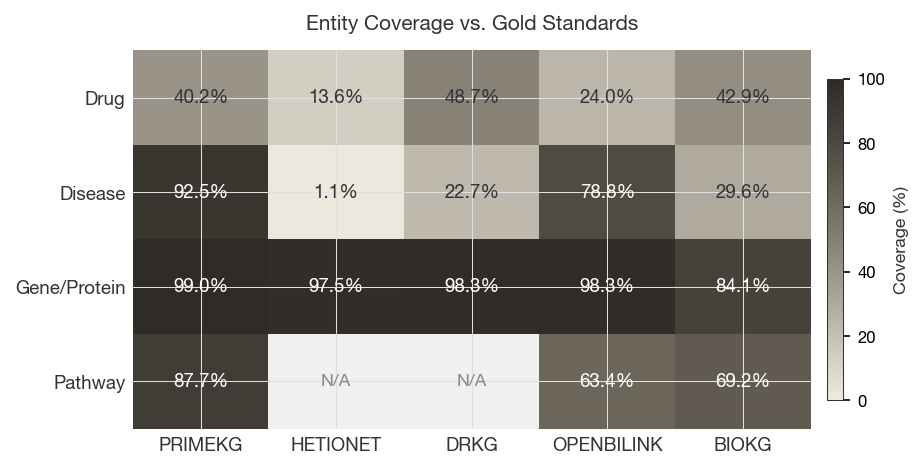

In [16]:
# Entity coverage heatmap - entity types x KGs
ENTITY_ORDER = [e for e in ['Drug', 'Disease', 'Gene/Protein', 'Pathway']
                if e in entity_summary['Entity Type'].values]

pivot = (entity_summary
         .pivot(index='Entity Type', columns='KG', values='Coverage (%)')
         .reindex(index=ENTITY_ORDER, columns=KG_NAMES))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
data, valid = pivot.values.astype(float), ~np.isnan(pivot.values)

im = ax.imshow(np.where(valid, data, np.nan),
               cmap=HEATMAP_CMAP, vmin=0, vmax=100, aspect='auto')
ax.imshow(np.where(~valid, 1, np.nan),
          cmap=mcolors.ListedColormap(['#f0f0f0']), vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([n.upper() for n in pivot.columns], fontsize=9, color=TEXT_COLOR)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9, color=TEXT_COLOR)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

for i, entity in enumerate(pivot.index):
    for j, kg in enumerate(pivot.columns):
        val = pivot.loc[entity, kg]
        if pd.notna(val):
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white' if val >= 55 else TEXT_COLOR)
        else:
            ax.text(j, i, 'N/A', ha='center', va='center',
                    fontsize=8.5, color='#888888', style='italic')

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Coverage (%)', fontsize=8.5, color=TEXT_COLOR)
ax.set_title('Entity Coverage vs. Gold Standards',
             fontsize=10, fontweight='bold', color=TEXT_COLOR, pad=10)

plt.tight_layout()
save_fig(fig, FIGS, '01_entity_coverage')
plt.show()

## 2. Relation Coverage

Relation coverage quantifies how many gold-standard entity pairs linked by a given relation type are present in the KG:

$$\text{Relation Coverage}_r = \frac{|\text{KG pairs}_r \cap \text{Gold pairs}_r|}{|\text{Gold pairs}_r|}$$

Relation names per KG are specified in `config.yaml` under each KG's `relations` key. KGs without a given relation configured are reported as N/A.

| Relation | Gold standard | Notes |
|---|---|---|
| Drug–target | DrugBank (approved/investigational) | HGNC→Entrez via UniProt |
| Drug–disease indication | Open Targets | MONDO-normalised; ~16% of pairs lack resolvable MONDO ID |
| Drug–drug interaction | DrugBank DDI | Unordered pairs |

In [17]:
# Relation helpers - edge filtering and pair extraction

def get_edges(kg: pd.DataFrame, rel_spec: dict) -> pd.DataFrame:
    """Filter edges by relation spec (keys: 'relation' or 'relations', optional 'display_relation')."""
    mask = (kg['relation'].isin(rel_spec['relations']) if 'relations' in rel_spec
            else kg['relation'] == rel_spec['relation'])
    if 'display_relation' in rel_spec:
        mask &= kg['display_relation'] == rel_spec['display_relation']
    return kg[mask]


def extract_pairs(kg: pd.DataFrame, rel_spec: dict,
                  normalise_disease: bool = False,
                  x_type_filter: Optional[str] = None,
                  y_type_filter: Optional[str] = None) -> set:
    """Return (x_id, y_id) pairs for a relation, stripping entity-type prefixes.

    normalise_disease maps y-side disease IDs to MONDO numeric via _to_mondo.
    """
    edges = get_edges(kg, rel_spec)
    if x_type_filter is not None:
        edges = edges[edges['x_type'] == x_type_filter]
    if y_type_filter is not None:
        edges = edges[edges['y_type'] == y_type_filter]

    x_ids = edges['x_id'].astype(str).map(_strip_prefix)
    y_ids = edges['y_id'].astype(str).map(_strip_prefix)
    if normalise_disease:
        y_ids = y_ids.map(_to_mondo)

    mask = x_ids.notna() & y_ids.notna()
    return set(zip(x_ids[mask], y_ids[mask]))

**Drug–target.** Gold standard: DrugBank drug–target pairs, filtered to approved and investigational compounds. DrugBank stores targets as HGNC gene symbols; UniProt human proteome mapping bridges to Entrez IDs. Each gold-standard pair is a `(DrugBank ID, Entrez ID)` tuple.

In [18]:
# Symbol -> Entrez mapping and drug-target gold standard
symbol_to_entrez = {
    sym.upper(): str(row['GeneID']).split(';')[0].strip()
    for _, row in uniprot.iterrows()
    if pd.notna(row['GeneID'])
    for sym in str(row.get('Gene Names', '')).split()
}

gold_drug_targets = {
    (row['drugbank_id'], entrez)
    for _, row in drugbank_relevant.iterrows()
    if pd.notna(row['target_genes'])
    for sym in str(row['target_genes']).split('|')
    if (entrez := symbol_to_entrez.get(sym.strip().upper()))
}
print(f'Gold standard - Drug-Target pairs: {len(gold_drug_targets):,}\n')

Gold standard - Drug-Target pairs: 13,430



In [19]:
# Drug-target coverage per KG
_no_result = {'coverage_pct': float('nan'), 'overlap_n': float('nan'),
              'gold_n': len(gold_drug_targets), 'matched': set(),
              'unmatched': gold_drug_targets}

dt_results = {}
for kg_name, data in kgs.items():
    rel_spec = KG_RELATIONS[kg_name].get('drug_target')
    if rel_spec is None:
        dt_results[kg_name] = _no_result
        print(f'{kg_name:12s}: N/A (no drug_target relation in config)')
        continue

    if kg_name == 'openbilink':
        # OpenBioLink drug-target edges carry PUBCHEM.COMPOUND:* on the drug side
        # and NCBIGENE:* on the gene side - both need normalisation to match gold pairs
        # (DrugBank accession, bare Entrez ID).
        emap  = ENTITY_TYPE_MAP[kg_name]
        edges = get_edges(data['kg'], rel_spec)
        drug_type = emap['Drug']
        gene_type = emap['Gene/Protein']
        fwd = edges[(edges['x_type'] == drug_type) & (edges['y_type'] == gene_type)]
        rev = edges[(edges['x_type'] == gene_type) & (edges['y_type'] == drug_type)]

        def _obl_dt_pairs(drug_col, gene_col, df):
            drug_ids = df[drug_col].map(_obl_pc_to_db)               # PubChem -> DrugBank
            gene_ids = df[gene_col].str.replace('NCBIGENE:', '', regex=False)
            valid    = drug_ids.notna() & gene_ids.notna()
            return set(zip(drug_ids[valid], gene_ids[valid]))

        obl_pairs = _obl_dt_pairs('x_id', 'y_id', fwd) | _obl_dt_pairs('y_id', 'x_id', rev)
        res = calc_coverage(obl_pairs, gold_drug_targets)
    elif kg_name == 'biokg':
        # BioKG: drugs are DrugBank IDs (match directly), genes are UniProt accessions
        # (need bridging to Entrez IDs via _uniprot_to_entrez).
        emap  = ENTITY_TYPE_MAP[kg_name]
        edges = get_edges(data['kg'], rel_spec)
        drug_type = emap['Drug']
        gene_type = emap['Gene/Protein']
        fwd = edges[(edges['x_type'] == drug_type) & (edges['y_type'] == gene_type)]
        rev = edges[(edges['x_type'] == gene_type) & (edges['y_type'] == drug_type)]

        def _biokg_dt_pairs(drug_col, gene_col, df):
            drug_ids = df[drug_col].astype(str).map(_strip_prefix)
            gene_ids = df[gene_col].astype(str).map(lambda x: _uniprot_to_entrez.get(_strip_prefix(x)))
            valid    = drug_ids.notna() & gene_ids.notna()
            return set(zip(drug_ids[valid], gene_ids[valid]))

        biokg_pairs = _biokg_dt_pairs('x_id', 'y_id', fwd) | _biokg_dt_pairs('y_id', 'x_id', rev)
        res = calc_coverage(biokg_pairs, gold_drug_targets)
    else:
        res = calc_coverage(extract_pairs(data['kg'], rel_spec), gold_drug_targets)

    dt_results[kg_name] = res
    print(f'{kg_name:12s}: {res["coverage_pct"]:5.1f}%  '
          f'({res["overlap_n"]:,} / {res["gold_n"]:,})')

primekg     :  70.0%  (9,398 / 13,430)
hetionet    :  29.6%  (3,971 / 13,430)
drkg        :  67.8%  (9,104 / 13,430)
openbilink  :  29.2%  (3,926 / 13,430)
biokg       :  71.2%  (9,564 / 13,430)


**Drug–disease indication.** Gold standard: Open Targets drug–disease indications with MONDO IDs. Disease IDs in KGs are normalised to MONDO according to the per-KG `disease_id_scheme` in config: MONDO-native KGs match directly (splitting compound IDs on the configured separator); other KGs bridge via DOID/MESH→MONDO tables. Pairs without a resolvable MONDO ID (~16% of Open Targets) are excluded from the denominator.

In [20]:
# Drug-disease gold standard from Open Targets
ot_ind['combined_mondo'] = ot_ind['mondo_id'].fillna(ot_ind['mondo_id_mapped'])
ot_mondo = (ot_ind[ot_ind['combined_mondo'].notna() &
                   ot_ind['drugbank_id'].isin(_db_all_ids)]
            .copy())
ot_mondo['mondo_norm'] = ot_mondo['combined_mondo'].astype(int).astype(str)
gold_drug_disease = set(zip(ot_mondo['drugbank_id'].astype(str), ot_mondo['mondo_norm']))
print(f'Gold standard - Drug-Disease pairs: {len(gold_drug_disease):,}  '
      f'({len(ot_mondo):,}/{len(ot_ind):,} with MONDO IDs)\n')

Gold standard - Drug-Disease pairs: 27,935  (27,935/33,390 with MONDO IDs)



In [21]:
# Drug-disease coverage per KG
def _extract_drug_disease_pairs(kg: pd.DataFrame, kg_name: str, rel_spec: dict) -> set:
    """Extract (drugbank_id, mondo_norm) pairs handling both MONDO-native and bridge-mapped KGs."""
    scheme = config['knowledge_graphs'][kg_name].get('disease_id_scheme', 'doid')
    if scheme != 'mondo':
        return extract_pairs(kg, rel_spec, normalise_disease=True)

    sep  = config['knowledge_graphs'][kg_name].get('disease_id_separator')
    emap = ENTITY_TYPE_MAP[kg_name]
    edges = get_edges(kg, rel_spec)
    fwd   = edges[(edges['x_type'] == emap['Drug'])    & (edges['y_type'] == emap['Disease'])]
    rev   = edges[(edges['x_type'] == emap['Disease']) & (edges['y_type'] == emap['Drug'])]

    pairs = set()
    for drug_col, dis_col, df in [('x_id', 'y_id', fwd), ('y_id', 'x_id', rev)]:
        for _, row in df.iterrows():
            for part in (str(row[dis_col]).split(sep) if sep else [str(row[dis_col])]):
                pairs.add((str(row[drug_col]), part.strip().lstrip('0')))
    return pairs


_no_result = {'coverage_pct': float('nan'), 'overlap_n': float('nan'),
              'gold_n': len(gold_drug_disease), 'matched': set(),
              'unmatched': gold_drug_disease}

dd_results = {}
for kg_name, data in kgs.items():
    rel_spec = KG_RELATIONS[kg_name].get('drug_disease')
    if rel_spec is None:
        dd_results[kg_name] = _no_result
        print(f'{kg_name:12s}: N/A (no drug_disease relation in config)')
        continue

    if kg_name == 'openbilink':
        # OpenBioLink drug-disease edges: drug side uses PUBCHEM.COMPOUND:* IDs
        # (needs PubChem -> DrugBank mapping); disease side uses DOID:* IDs
        # (needs DOID -> MONDO bridge to match Open Targets gold standard).
        emap      = ENTITY_TYPE_MAP[kg_name]
        edges     = get_edges(data['kg'], rel_spec)
        drug_type = emap['Drug']
        dis_type  = emap['Disease']
        fwd = edges[(edges['x_type'] == drug_type) & (edges['y_type'] == dis_type)]
        rev = edges[(edges['x_type'] == dis_type)  & (edges['y_type'] == drug_type)]

        def _obl_dd_pairs(drug_col, dis_col, df):
            drug_ids = df[drug_col].map(_obl_pc_to_db)          # PubChem -> DrugBank
            dis_ids  = df[dis_col].astype(str).map(_to_mondo)   # DOID:* -> MONDO numeric
            valid    = drug_ids.notna() & dis_ids.notna()
            return set(zip(drug_ids[valid], dis_ids[valid]))

        obl_pairs = _obl_dd_pairs('x_id', 'y_id', fwd) | _obl_dd_pairs('y_id', 'x_id', rev)
        res = calc_coverage(obl_pairs, gold_drug_disease)
    else:
        res = calc_coverage(_extract_drug_disease_pairs(data['kg'], kg_name, rel_spec),
                            gold_drug_disease)

    dd_results[kg_name] = res
    print(f'{kg_name:12s}: {res["coverage_pct"]:5.1f}%  '
          f'({res["overlap_n"]:,} / {res["gold_n"]:,})')

primekg     :   7.7%  (2,152 / 27,935)
hetionet    :   1.8%  (504 / 27,935)
drkg        :   4.4%  (1,220 / 27,935)
openbilink  :   5.2%  (1,466 / 27,935)
biokg       :  11.0%  (3,077 / 27,935)


**Drug–drug interaction.** Gold standard: DrugBank DDI pairs (unordered). KGs without a `drug_drug` relation configured in `config.yaml` are reported as N/A — this is appropriate when the KG encodes something other than clinical DDI (e.g. structural similarity) under that relation slot.

In [22]:
# Drug-drug interaction gold standard and coverage
gold_ddi = {
    tuple(sorted([row['drug1_id'], row['drug2_id']]))
    for _, row in drugbank_ddi.iterrows()
    if row['drug1_id'] in _db_all_ids and row['drug2_id'] in _db_all_ids
}
print(f'Gold standard - Drug-Drug pairs: {len(gold_ddi):,}\n')

_no_result = {'coverage_pct': float('nan'), 'overlap_n': float('nan'),
              'gold_n': len(gold_ddi), 'matched': set(), 'unmatched': gold_ddi}

ddi_results = {}
for kg_name, data in kgs.items():
    rel_spec = KG_RELATIONS[kg_name].get('drug_drug')
    if rel_spec is None:
        ddi_results[kg_name] = _no_result
        print(f'{kg_name:12s}: N/A (no drug_drug relation in config)')
        continue
    res = calc_coverage(
        {tuple(sorted(p)) for p in extract_pairs(data['kg'], rel_spec)},
        gold_ddi)
    ddi_results[kg_name] = res
    print(f'{kg_name:12s}: {res["coverage_pct"]:5.1f}%  '
          f'({res["overlap_n"]:,} / {res["gold_n"]:,})')

Gold standard - Drug-Drug pairs: 1,454,734

primekg     :  85.6%  (1,245,332 / 1,454,734)
hetionet    : N/A (no drug_drug relation in config)
drkg        :  83.2%  (1,209,737 / 1,454,734)
openbilink  : N/A (no drug_drug relation in config)
biokg       :  84.3%  (1,226,389 / 1,454,734)


### Visualisation

  → Saved: 01_relation_coverage.pdf / .png


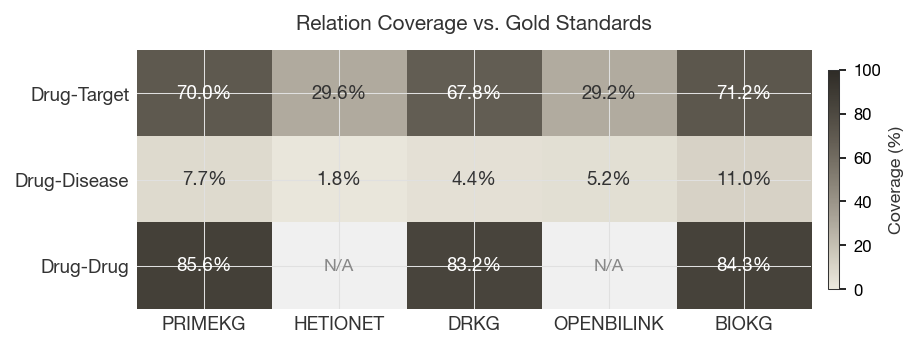

In [23]:
# Relation coverage heatmap - relation types x KGs (mirrors entity coverage heatmap style)
RELATION_RESULTS = {
    'Drug-Target':  dt_results,
    'Drug-Disease': dd_results,
    'Drug-Drug':    ddi_results,
}

relation_summary = pd.DataFrame([
    {'KG': kg_name, 'Relation': rel_label,
     'Coverage (%)': res['coverage_pct'],
     'Overlap': res['overlap_n'], 'Gold': res['gold_n']}
    for rel_label, results in RELATION_RESULTS.items()
    for kg_name, res in results.items()
])

RELATION_ORDER = list(RELATION_RESULTS.keys())

pivot_rel = (relation_summary
             .pivot(index='Relation', columns='KG', values='Coverage (%)')
             .reindex(index=RELATION_ORDER, columns=KG_NAMES))

fig, ax = plt.subplots(figsize=(6.5, 2.4))
data_rel = pivot_rel.values.astype(float)
valid_rel = ~np.isnan(data_rel)

im = ax.imshow(np.where(valid_rel, data_rel, np.nan),
               cmap=HEATMAP_CMAP, vmin=0, vmax=100, aspect='auto')
ax.imshow(np.where(~valid_rel, 1, np.nan),
          cmap=mcolors.ListedColormap(['#f0f0f0']), vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(pivot_rel.columns)))
ax.set_xticklabels([n.upper() for n in pivot_rel.columns], fontsize=9, color=TEXT_COLOR)
ax.set_yticks(range(len(pivot_rel.index)))
ax.set_yticklabels(pivot_rel.index, fontsize=9, color=TEXT_COLOR)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

for i, rel in enumerate(pivot_rel.index):
    for j, kg in enumerate(pivot_rel.columns):
        val = pivot_rel.loc[rel, kg]
        if pd.notna(val):
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white' if val >= 55 else TEXT_COLOR)
        else:
            ax.text(j, i, 'N/A', ha='center', va='center',
                    fontsize=8.5, color='#888888', style='italic')

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Coverage (%)', fontsize=8.5, color=TEXT_COLOR)
ax.set_title('Relation Coverage vs. Gold Standards',
             fontsize=10, fontweight='bold', color=TEXT_COLOR, pad=10)

plt.tight_layout()
save_fig(fig, FIGS, '01_relation_coverage')
plt.show()

### Diagnostic: Relation Coverage Gaps

Missing relation pairs may stem from (a) entities absent from the KG entirely, (b) entities present but the relation not curated, or (c) ID-mapping failures preventing the match. The table below separates these causes for each relation type.

In [24]:
# Relation gap decomposition: why are pairs missing?
# For each missing gold pair (x, y), classify into:
#   - "both entities absent"  — neither x nor y in the KG
#   - "one entity absent"     — one of x/y not in the KG
#   - "relation not curated"  — both entities present but pair not linked

_REL_GOLD = {
    'Drug-Target':  gold_drug_targets,
    'Drug-Disease': gold_drug_disease,
    'Drug-Drug':    gold_ddi,
}

print('Relation gap decomposition\n')
rel_gap_rows = []
for rel_label, results in RELATION_RESULTS.items():
    gold_pairs = _REL_GOLD[rel_label]
    for kg_name, res in results.items():
        if isinstance(res['overlap_n'], float) and math.isnan(res['overlap_n']):
            continue  # N/A
        unmatched_pairs = res['unmatched']
        if not unmatched_pairs:
            continue

        # Build entity sets present in this KG (drugs and targets/diseases)
        kg_drug_set = entity_sets[kg_name].get('Drug', set())
        if rel_label == 'Drug-Target':
            kg_other_set = entity_sets[kg_name].get('Gene/Protein', set())
        elif rel_label == 'Drug-Disease':
            # MONDO-normalised disease set
            cfg = config['knowledge_graphs'][kg_name]
            if cfg.get('disease_id_scheme') == 'mondo':
                kg_other_set = entity_sets[kg_name].get('Disease', set())
            else:
                kg_other_set = {
                    doid_to_mondo.get(d) for d in entity_sets[kg_name].get('Disease', set())
                } - {None}
        else:  # Drug-Drug
            kg_other_set = kg_drug_set

        n_both_absent, n_one_absent, n_not_curated = 0, 0, 0
        for x, y in unmatched_pairs:
            x_in = x in kg_drug_set
            y_in = y in (kg_drug_set if rel_label == 'Drug-Drug' else kg_other_set)
            if not x_in and not y_in:
                n_both_absent += 1
            elif not x_in or not y_in:
                n_one_absent += 1
            else:
                n_not_curated += 1

        n_miss = len(unmatched_pairs)
        print(f'  {kg_name:12s} / {rel_label:14s}:  {n_miss:>8,} missing')
        print(f'    {"Both absent":22s}  {n_both_absent:>8,}  ({100*n_both_absent/n_miss:5.1f}%)')
        print(f'    {"One absent":22s}  {n_one_absent:>8,}  ({100*n_one_absent/n_miss:5.1f}%)')
        print(f'    {"Relation not curated":22s}  {n_not_curated:>8,}  ({100*n_not_curated/n_miss:5.1f}%)')
        rel_gap_rows.append({
            'KG': kg_name, 'Relation': rel_label,
            'Missing': n_miss,
            'Both Absent': n_both_absent,
            'One Absent': n_one_absent,
            'Not Curated': n_not_curated,
        })

print()
if rel_gap_rows:
    pd.DataFrame(rel_gap_rows).set_index(['KG', 'Relation'])

Relation gap decomposition

  primekg      / Drug-Target   :     4,032 missing
    Both absent                    0  (  0.0%)
    One absent                 1,970  ( 48.9%)
    Relation not curated       2,062  ( 51.1%)
  hetionet     / Drug-Target   :     9,459 missing
    Both absent                    3  (  0.0%)
    One absent                 8,099  ( 85.6%)
    Relation not curated       1,357  ( 14.3%)
  drkg         / Drug-Target   :     4,326 missing
    Both absent                    0  (  0.0%)
    One absent                 1,233  ( 28.5%)
    Relation not curated       3,093  ( 71.5%)
  openbilink   / Drug-Target   :     9,504 missing
    Both absent                    0  (  0.0%)
    One absent                 4,986  ( 52.5%)
    Relation not curated       4,518  ( 47.5%)
  biokg        / Drug-Target   :     3,866 missing
    Both absent                    2  (  0.1%)
    One absent                 1,781  ( 46.1%)
    Relation not curated       2,083  ( 53.9%)
  primekg   

In [25]:
# Checkpoint - save scalar coverage results for downstream notebooks
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

def _scalar(res: dict) -> dict:
    """Extract scalar stats from a coverage result dict (strips large ID sets)."""
    ovl = res['overlap_n']
    return {
        'pct':     res['coverage_pct'],
        'overlap': int(ovl) if not (isinstance(ovl, float) and math.isnan(ovl)) else None,
        'gold':    int(res['gold_n']),
    }

# --- Entity coverage (per eligible entity type) ---
entity_cov = {
    kg_name: {
        et: round(len(kg_set & GOLD_SETS[et]) / len(GOLD_SETS[et]), 4)
        for et, kg_set in sets.items()
        if et in GOLD_SETS and _eligible(kg_name, et)
    }
    for kg_name, sets in entity_sets.items()
}

# --- Relation coverage (per relation type, 0-1 scale) ---
relation_cov_raw = {
    kg: {
        'drug_target':  _scalar(dt_results[kg]),
        'drug_disease': _scalar(dd_results[kg]),
        'drug_drug':    _scalar(ddi_results[kg]),
    }
    for kg in KG_NAMES
}

# --- Summary score: shared types only (fair cross-KG comparison) ---
# Entity types present in ALL KGs
SHARED_ENTITY_TYPES = sorted(
    set.intersection(*(set(entity_cov[kg].keys()) for kg in KG_NAMES))
)
# Relation types with valid (non-NaN) data in ALL KGs
SHARED_RELATION_TYPES = sorted([
    rtype for rtype in ['drug_target', 'drug_disease', 'drug_drug']
    if all(
        relation_cov_raw[kg][rtype]['pct'] is not None
        and not (isinstance(relation_cov_raw[kg][rtype]['pct'], float)
                 and math.isnan(relation_cov_raw[kg][rtype]['pct']))
        for kg in KG_NAMES
    )
])

print(f'Shared entity types for scoring:   {SHARED_ENTITY_TYPES}')
print(f'Shared relation types for scoring: {SHARED_RELATION_TYPES}')

sub_scores = {}
for kg in KG_NAMES:
    # Entity coverage: mean over shared types only
    s_entity = round(float(np.mean([
        entity_cov[kg][et] for et in SHARED_ENTITY_TYPES
    ])), 4)

    # Relation coverage: mean over shared types only
    s_relation = round(float(np.mean([
        relation_cov_raw[kg][rt]['pct'] / 100.0
        for rt in SHARED_RELATION_TYPES
    ])), 4)

    sub_scores[kg] = {
        'entity_coverage':   s_entity,
        'relation_coverage': s_relation,
    }

# Summary = equal-weighted mean of entity and relation coverage
summary_scores = {
    kg: round(float(np.mean(list(sub_scores[kg].values()))), 4)
    for kg in KG_NAMES
}

ckpt = {
    'summary_scores':    summary_scores,
    'sub_scores':        sub_scores,
    'entity_cov':        entity_cov,           # full per-type detail (incl. non-shared)
    'relation_coverage': relation_cov_raw,      # full per-type detail (incl. non-shared)
    'shared_entity_types':   SHARED_ENTITY_TYPES,
    'shared_relation_types': SHARED_RELATION_TYPES,
    'kg_stats': {
        name: {
            'n_edges':     int(len(data['kg'])),
            'n_nodes':     int(len(data['nodes'])),
            'n_relations': int(data['kg']['relation'].nunique()),
        }
        for name, data in kgs.items()
    },
}

out = CKPT_DIR / '01_coverage.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)

print(f'\nCheckpoint saved: {out}')
print(f'\n{"KG":<12s}  {"Entity":>9s}  {"Relation":>9s}  {"Overall":>9s}')
print('  ' + '-' * 36)
for name in KG_NAMES:
    ss = sub_scores[name]
    print(f'{name:<12s}  {ss["entity_coverage"]:>9.3f}  {ss["relation_coverage"]:>9.3f}  '
          f'{summary_scores[name]:>9.3f}')

Shared entity types for scoring:   ['Disease', 'Drug', 'Gene/Protein']
Shared relation types for scoring: ['drug_disease', 'drug_target']

Checkpoint saved: /Users/shil6661/BioKGBench/results/checkpoints/01_coverage.pkl

KG               Entity   Relation    Overall
  ------------------------------------
primekg           0.772      0.388      0.580
hetionet          0.374      0.157      0.266
drkg              0.566      0.361      0.463
openbilink        0.670      0.172      0.421
biokg             0.522      0.411      0.467


## Dimension Score

The coverage dimension score combines the two sub-metrics:

$$\text{Coverage} = \frac{1}{2}\left(\text{Entity Coverage} + \text{Relation Coverage}\right)$$

Each sub-metric is the mean across **shared types only** — entity/relation types that are present and evaluable in **all** KGs. This ensures fair cross-KG comparison:

- **Entity types excluded from scoring** if not present in all KGs (e.g., Pathway is excluded because not all KGs use Reactome ontology).
- **Relation types excluded from scoring** if any KG reports N/A (e.g., Drug–Drug is excluded because Hetionet does not define this relation).

Full per-type detail is still saved in the checkpoint for supplementary analysis.